In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numba import cuda, float64, complex128
from numba.cuda import jit as cuda_jit
import math

import few

from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode import KerrEccEqFlux
from few.amplitude.ampinterp2d import AmpInterpKerrEccEq
from few.summation.interpolatedmodesum import InterpolatedModeSum 


from few.utils.ylm import GetYlms

from few import get_file_manager

from few.waveform import GenerateEMRIWaveform, FastKerrEccentricEquatorialFlux

from few.utils.geodesic import get_fundamental_frequencies

from few.utils.constants import YRSID_SI
from smt.sampling_methods import LHS


import os
import sys

# Changing directory to work dir
# to import my modules
dir_work ='/nfs/home/svu/e1498138/localgit/FEWNEW/work/'

os.chdir(dir_work)
sys.path.insert(0, dir_work)

import GWfuncs
import loglike_timemax_T  # TIME-MAXIMIZED VERSION, with T as param
# import modeselectoralt
import parismc
# import gc
import pickle
import cupy as cp

# tune few configuration
cfg_set = few.get_config_setter(reset=True)
cfg_set.set_log_level("info")

# GPU configuration 
use_gpu = True
force_backend = "cuda12x"  
dt = 10     # Time step
T = 2     # Total time
print(f"Using dt = {dt} seconds, T = {T} years")

print('Initializing waveform generator...')
# keyword arguments for inspiral generator 
inspiral_kwargs={
        "func": 'KerrEccEqFlux',
        "DENSE_STEPPING": 0, #change to 1/True for uniform sampling
        "include_minus_m": False, 
}

# keyword arguments for inspiral generator 
amplitude_kwargs = {
    "force_backend": force_backend # Force GPU
}

# keyword arguments for Ylm generator (GetYlms)
Ylm_kwargs = {
    "force_backend": force_backend,  # Force GPU
    # "assume_positive_m": True  # if we assume positive m, it will generate negative m for all m>0
}

# keyword arguments for summation generator (InterpolatedModeSum)
sum_kwargs_comb = {
    "force_backend": force_backend,  # Force GPU
    "pad_output": True,
}

sum_kwargs_sep = {
    "force_backend": force_backend,  # Force GPU
    "pad_output": True,
    "separate_modes": True,
}

print("Creating GenerateEMRIWaveform class...")
# Kerr eccentric flux
waveform_gen_comb = GenerateEMRIWaveform(
    FastKerrEccentricEquatorialFlux, 
    frame='detector',
    inspiral_kwargs=inspiral_kwargs, 
    amplitude_kwargs=amplitude_kwargs, 
    Ylm_kwargs=Ylm_kwargs,
    sum_kwargs=sum_kwargs_comb,
    use_gpu=use_gpu
)

# Kerr eccentric flux
waveform_gen_sep = GenerateEMRIWaveform(
    FastKerrEccentricEquatorialFlux, 
    frame='detector',
    inspiral_kwargs=inspiral_kwargs, 
    amplitude_kwargs=amplitude_kwargs, 
    Ylm_kwargs=Ylm_kwargs,
    sum_kwargs=sum_kwargs_sep,
    use_gpu=use_gpu
)


print('Done initializing waveform generator.')

print("Creating GravWaveAnalysis class...")
gwf = GWfuncs.GravWaveAnalysis(T, dt)

print("Initializing loglike class...")


# Source parameters
m1 = 1e6
m2 = 1e1
a = 0.7
p0 = 9
e0 = 0.4
xI0 = 1.0
dist = 1.8  # Gpc
qS = np.pi
phiS = 0.
qK =  0.
phiK = 0.
Phi_phi0 = 0.4
Phi_theta0 = 0.0
Phi_r0 = 0.5

params_star = (m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0)
param_true = [np.log10(m1), np.log10(m2), a, p0, e0]

# n-indexed mode selection parameters
n_vals = np.arange(-1,6)  # n from -1 to 5
ell = 2  # quadrupole only

# NOTE: change verbose argument for debugging
# Using n-indexed mode selection
loglike_obj = loglike_timemax_T.LogLike(
    params_star,
    waveform_gen_comb,
    gwf,
    verbose=False,
    waveform_gen_sep=waveform_gen_sep,
    ell=ell,
    n_vals=n_vals,
    M_mode=None  # No SNR filtering, use all n-groups
)

print('Done initializing loglike class.')
print('Calculating SNR...')
data = loglike_obj.signal
data_snr = gwf.rhostat(data)
print('SNR calculated:', data_snr)
print("Setting up log_density and prior functions...")

# annealing dict
anneal_state = {
    'S':          3.0,
    'stage':      0,
    'ref_max_ld': None,
    'ref_iter':   0,
}

S_schedule  = [3.0, 10.0, 30.0, 100.0]
stuck_iters = 10000

def log_density(params):
    params = np.asarray(params)

    n_samples = params.shape[0] 
    log_likes = np.zeros(n_samples)


    for i in range(n_samples):
        logm1, logm2, a, p0, e0, T_prop = params[i]
        m1 = 10**logm1
        m2 = 10**logm2

        try:
            loglike = loglike_obj(np.array([m1, m2, a, p0, e0, xI0,
                                            dist, qS, phiS, qK, phiK,
                                            Phi_phi0, Phi_theta0, Phi_r0,
                                            T_prop])) * anneal_state['S']
        except Exception:
            loglike = -np.inf
        log_likes[i] = loglike

    return log_likes

def prior_transform(u):
    logm1lim = [5.6, 6.4]
    logm2lim = [0.8,1.3]
    alim = [0.3, 0.99]
    p0lim = [8.0, 11.0]
    e0lim = [0.2, 0.5]
    Tlim = [3/12,2]

    transformed = np.zeros_like(u)

    # Uniform in log for masses

    # m1
    transformed[:, 0] = (logm1lim[1] - logm1lim[0]) * u[:, 0] + logm1lim[0]

    # m2
    transformed[:, 1] = (logm2lim[1] - logm2lim[0]) * u[:, 1] + logm2lim[0]

    # Linear in others

    # a
    transformed[:, 2] = (alim[1] - alim[0]) * u[:, 2] + alim[0]

    # p0
    transformed[:, 3] = (p0lim[1] - p0lim[0]) * u[:, 3] + p0lim[0]

    # e0
    transformed[:, 4] = (e0lim[1] - e0lim[0]) * u[:, 4] + e0lim[0]

    # T
    transformed[:, 5] = (Tlim[1] - Tlim[0]) * u[:, 5] + Tlim[0]


    return transformed

def inverse_prior_transform(params):
    logm1lim = [5.6, 6.4]
    logm2lim = [0.8, 1.3]
    alim = [0.3, 0.99]
    p0lim = [8.0, 11.0]
    e0lim = [0.2, 0.5]
    Tlim = [3/12,2]

    params = np.asarray(params)
    u = np.zeros_like(params)

    u[:, 0] = (params[:, 0] - logm1lim[0]) / (logm1lim[1] - logm1lim[0])
    u[:, 1] = (params[:, 1] - logm2lim[0]) / (logm2lim[1] - logm2lim[0])
    u[:, 2] = (params[:, 2] - alim[0]) / (alim[1] - alim[0])
    u[:, 3] = (params[:, 3] - p0lim[0]) / (p0lim[1] - p0lim[0])
    u[:, 4] = (params[:, 4] - e0lim[0]) / (e0lim[1] - e0lim[0])
    u[:, 5] = (params[:, 5] - Tlim[0]) / (Tlim[1] - Tlim[0])                                                                                                                                                 

    return u



print('Done setting up log-likelihood and prior.')

Using dt = 10 seconds, T = 2 years
Initializing waveform generator...
Creating GenerateEMRIWaveform class...
Done initializing waveform generator.
Creating GravWaveAnalysis class...
Initializing loglike class...
Done initializing loglike class.
Calculating SNR...
SNR calculated: 32.86622400746991
Setting up log_density and prior functions...
Done setting up log-likelihood and prior.


In [2]:
dir_scratch = '/scratch/e1498138/'
savepath = dir_scratch + 'paris2/int_3mth_snr32_dur_anneal'


In [3]:
sampler = parismc.Sampler.load_state(savepath+'/sampler_state.pkl')

In [4]:
samples, weights = sampler.get_samples_with_weights(flatten=True)

In [5]:
proc_pt = sampler.searched_points_list
proc_pt

[array([[ 5.34637162e-01,  6.37650360e-01,  5.53450101e-01,
          3.74504457e-01,  4.04698067e-01,  0.00000000e+00],
        [ 4.40062573e-01,  7.00317799e-01,  4.74841857e-01,
          3.39316363e-01,  4.34475116e-01, -4.19875750e-04],
        [ 5.39298453e-01,  3.78204970e-01,  2.90189549e-01,
          2.73906985e-01,  3.05886623e-01, -1.07760140e-03],
        ...,
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00]],
       shape=(100000, 6))]

In [6]:
logden_list = sampler.searched_log_densities_list
logden_list

[array([8.81544249,       -inf,       -inf, ..., 0.        , 0.        ,
        0.        ], shape=(100000,))]

In [7]:
sampler.now_covariances

[array([[ 3.38957622e-08,  1.69378366e-08,  7.94668047e-08,
         -5.30623980e-08,  2.01361073e-09, -3.68505813e-07],
        [ 1.69378366e-08,  9.81391848e-09,  3.92379370e-08,
         -2.50019943e-08, -5.50076702e-10, -1.88261298e-07],
        [ 7.94668047e-08,  3.92379370e-08,  1.87370894e-07,
         -1.26169542e-07,  5.28073372e-09, -8.63787224e-07],
        [-5.30623980e-08, -2.50019943e-08, -1.26169542e-07,
          1.46971266e-07,  3.34709457e-08,  4.66806771e-07],
        [ 2.01361073e-09, -5.50076702e-10,  5.28073372e-09,
          3.34709457e-08,  2.68524253e-08, -8.56729538e-08],
        [-3.68505813e-07, -1.88261298e-07, -8.63787224e-07,
          4.66806771e-07, -8.56729538e-08,  4.36105998e-06]])]

In [8]:
np.argmax(logden_list)

np.int64(96902)

In [9]:
maxld_pt1 = prior_transform(proc_pt[0][np.argmax(logden_list)].reshape(1, -1))
maxld_pt1

array([[5.99928361, 0.9997316 , 0.69857945, 8.00322277, 0.33406888,
        0.83600633]])

In [10]:
log_density(maxld_pt1)

array([59.64011993])

In [17]:
param_true = np.array([np.log10(m1), np.log10(m2), a, p0, e0, T])
param_true

array([6. , 1. , 0.7, 9. , 0.4, 2. ])

In [13]:
log_density(param_true.reshape(1,-1))

array([97.0109404])

In [18]:
param_ranges = [(5.6,6.4),
                (0.8,1.3),
                (0.3,0.99),
                (8.0,11.0),
                (0.2,0.5),
                (3/12,2)
                ]
param_ranges

[(5.6, 6.4), (0.8, 1.3), (0.3, 0.99), (8.0, 11.0), (0.2, 0.5), (0.25, 2)]

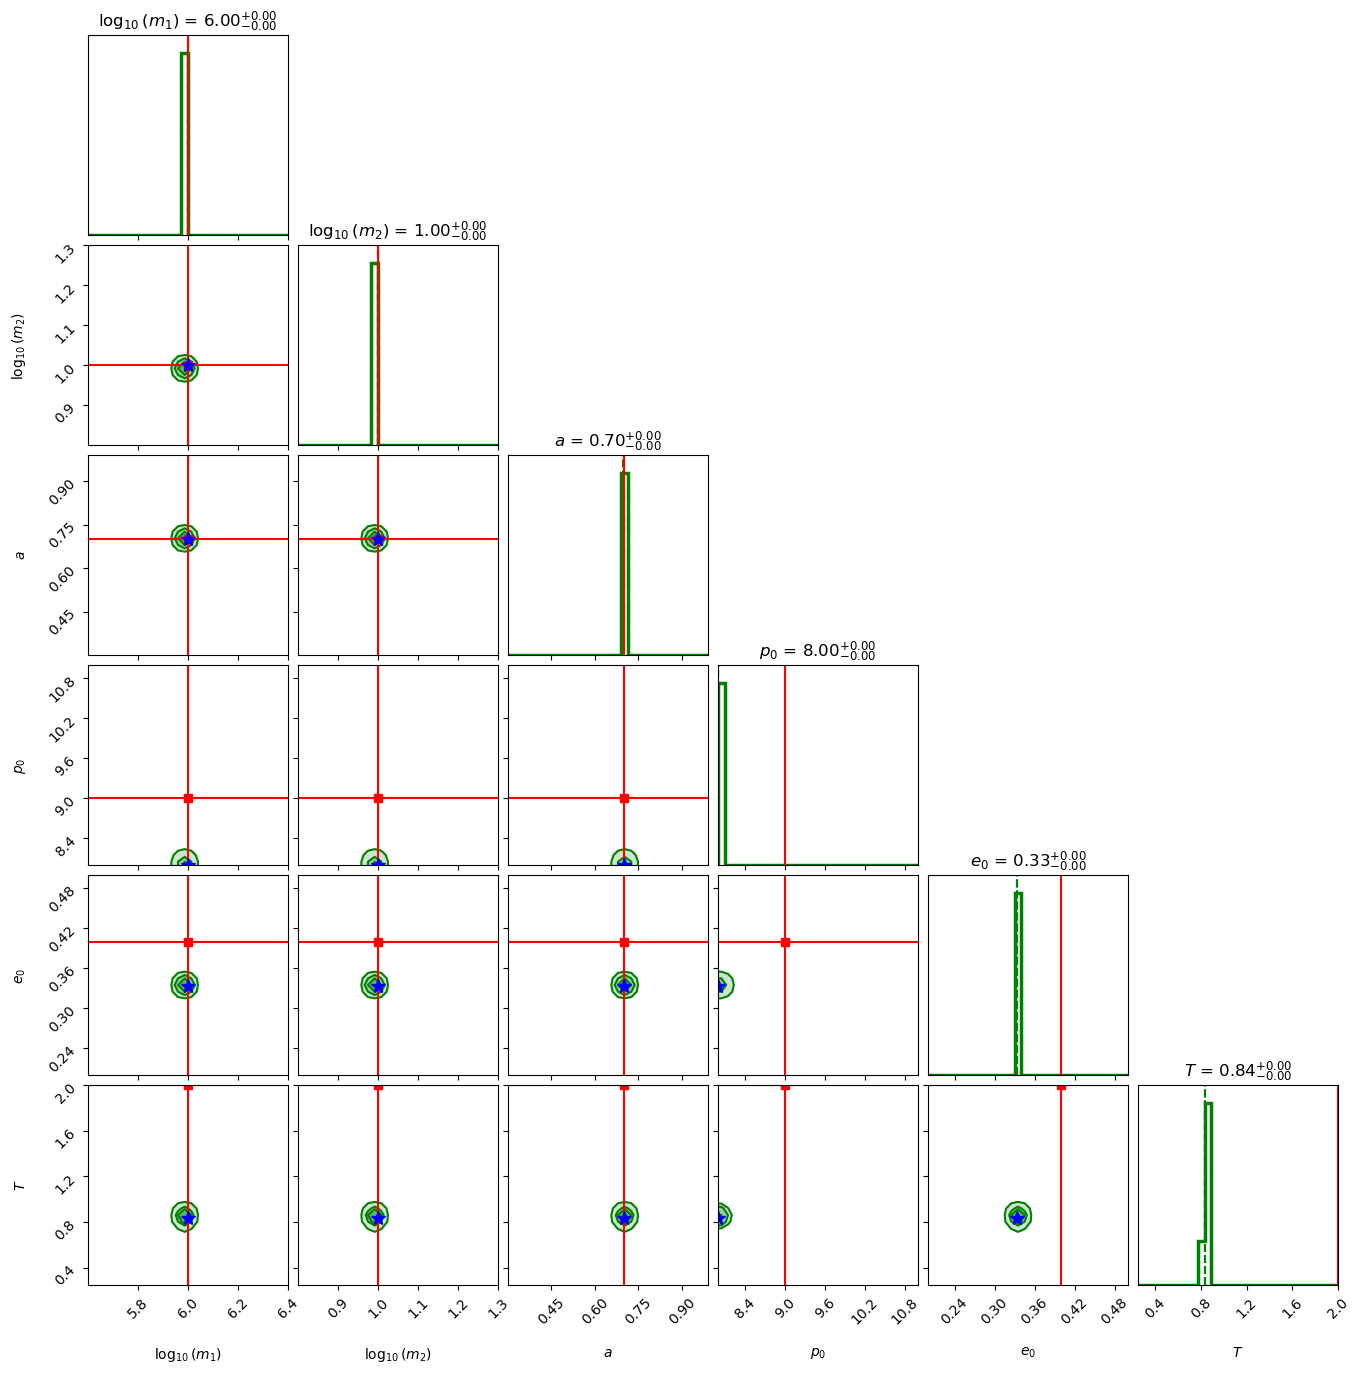

In [19]:
import corner
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$',r'$T$']
fig = corner.corner(
    samples,
    weights=weights,
    labels=labels,
    truths=param_true,
    truth_color='red',
    color='green',
    show_titles=True,
    label_kwargs={"fontsize": 10},
    title_kwargs={"fontsize": 12},
    quantiles=[0.16, 0.5, 0.84],
    smooth=True,
    bins=30,
    plot_datapoints=False,
    hist_kwargs={"density": True, 'linewidth': 2.5},
    linewidth=2.5,
    fill_contours=True,
    range = param_ranges
)

corner.overplot_points(fig, maxld_pt1.reshape(1, -1), 
                       color='blue', marker='*', ms=10, 
                       reverse=False)




# connection plot

In [20]:
proc1_maxld_pt = maxld_pt1.copy()
proc1_maxld_pt

array([[5.99928361, 0.9997316 , 0.69857945, 8.00322277, 0.33406888,
        0.83600633]])

In [21]:
# connect two highest logden pts

proc1_maxld_pt_1d = proc1_maxld_pt[0] 
true_pt = np.array(param_true)

# NOTE: connecting only till the true/target pt 
n_points = 50
t_values = np.linspace(0, 1, n_points)  # extend beyond each endpoint
line_points_proc1 = proc1_maxld_pt_1d[:, np.newaxis] + t_values * (true_pt - proc1_maxld_pt_1d)[:, np.newaxis]


In [22]:
logden_theory_proc1 = []
logden_theory_proc1.append(log_density(np.array(line_points_proc1).T))


In [23]:
logden_theory_proc1 = np.array(logden_theory_proc1).flatten()


In [24]:
logden_theory_proc1

array([59.64011993, 32.45039481, 18.60990808, 11.61900541,  8.17750604,
        6.07584869,  4.78112218,  4.10867422,  3.71740832,  3.30834088,
        3.02997085,  2.70328202,  2.53965447,  2.36036131,  2.26436036,
        2.02586022,  2.03411117,  1.96062067,  1.79779366,  1.86313212,
        1.82197866,  1.78615141,  1.65516877,  1.73070466,  1.72343544,
        1.67172616,  1.71790736,  1.64064353,  1.65467421,  1.78115365,
        1.65674218,  1.77153084,  1.75327458,  1.92521799,  1.84436808,
        1.95944062,  2.05511333,  2.37419098,  2.49887572,  2.70917329,
        2.93492917,  3.16943879,  3.27889152,  4.14776053,  5.04295567,
        6.75127803,  9.25716201, 11.84034527, 26.91941834, 97.0109404 ])

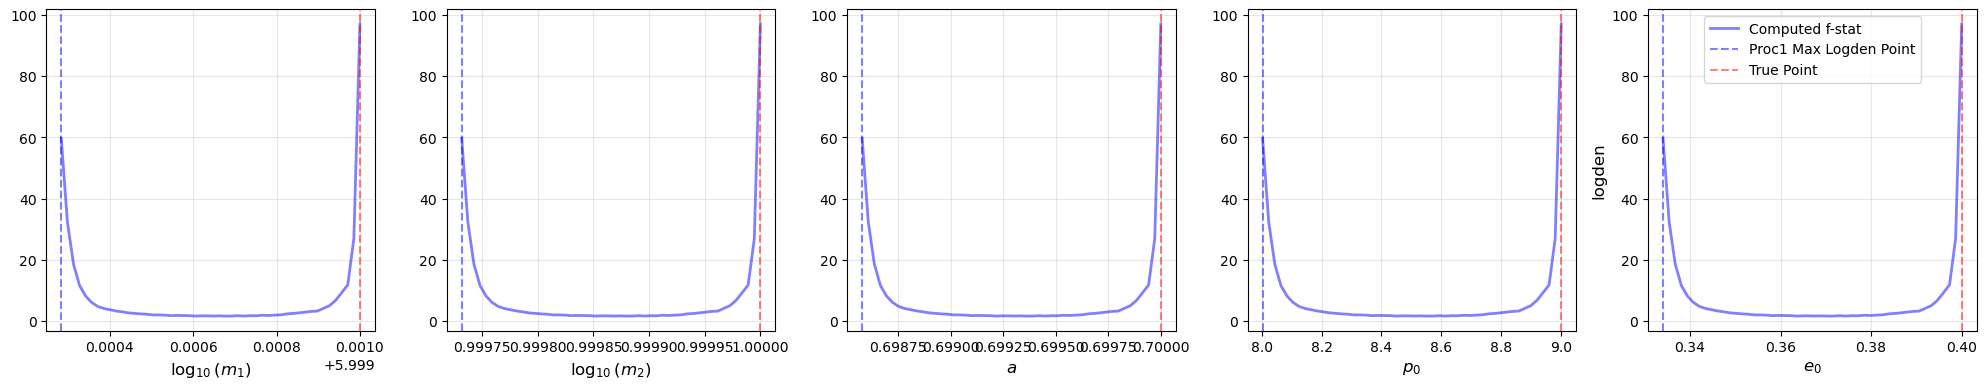

In [25]:
import matplotlib.pyplot as plt
fig_1d, axs_1d = plt.subplots(1, 5, figsize=(20, 4))
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$', r'$T$']
plt.ylabel('logden', fontsize=12)
for dim in range(5):
    ax = axs_1d[dim]

    # Plot theoretical log-density
    ax.plot(line_points_proc1[dim], logden_theory_proc1, '-', 
            color='blue', alpha=0.5, linewidth=2, label='Computed f-stat')


    # Mark the max likelihood points
    ax.axvline(proc1_maxld_pt_1d[dim], color='blue', linestyle='--', 
               alpha=0.5, label=f'Proc1 Max Logden Point')
    ax.axvline(param_true[dim], color='red', linestyle='--', 
               alpha=0.5, label='True Point')
    
    ax.set_xlabel(labels[dim], fontsize=12)
    # ax.set_ylabel('logden', fontsize=12)
    ax.grid(True, alpha=0.3)

plt.legend()
plt.tight_layout()
